# Bird-Meteo Exploration

This notebook explores the correlation between bird sightings in Switzerland and local weather conditions.

## 1. Setup

In [1]:
%load_ext autoreload
%autoreload 2

import sqlite3
import pandas as pd
import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Add src to path
sys.path.append(os.path.abspath('../'))

from src.weather_api import get_weather_data

# Set style
sns.set_theme(style="whitegrid")

## 2. Load eBird Data

Load data from `data/ebird.db` for the year 2024.

In [2]:
db_path = '../data/ebird.db'
conn = sqlite3.connect(db_path)

# Load observations for 2024 to keep it manageable
query = """
SELECT common_name, latitude, longitude, observation_date, time_observations_started 
FROM observations 
WHERE observation_date LIKE '2024-%'
"""
df_obs = pd.read_sql(query, conn)
df_obs['observation_date'] = pd.to_datetime(df_obs['observation_date'])
df_obs.head()

,common_name,latitude,longitude,observation_date,time_observations_started
0,Bar-headed Goose,47.583332,8.233332,2024-01-20,10:09:00
1,Bar-headed Goose,47.583332,8.233332,2024-01-11,13:33:00
2,Bar-headed Goose,47.583332,8.233332,2024-01-05,09:11:00
3,Bar-headed Goose,47.583332,8.233332,2024-01-20,09:19:00
4,Bar-headed Goose,47.583332,8.233332,2024-01-05,08:45:00


## 3. Basic EDA

### 3.1 Top Species

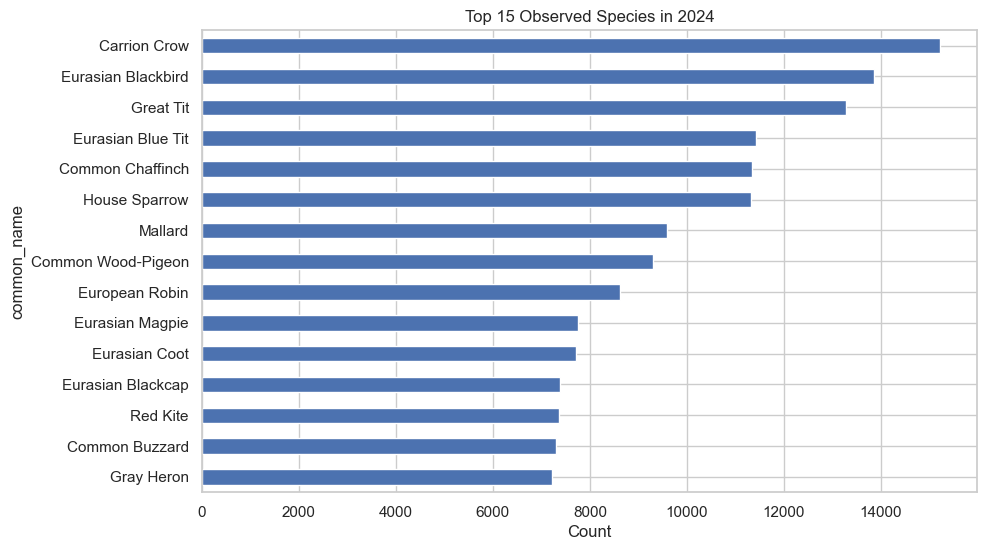

In [3]:
plt.figure(figsize=(10, 6))
df_obs['common_name'].value_counts().head(15).plot(kind='barh')
plt.title('Top 15 Observed Species in 2024')
plt.xlabel('Count')
plt.gca().invert_yaxis()
plt.show()

### 3.2 Seasonal Distribution

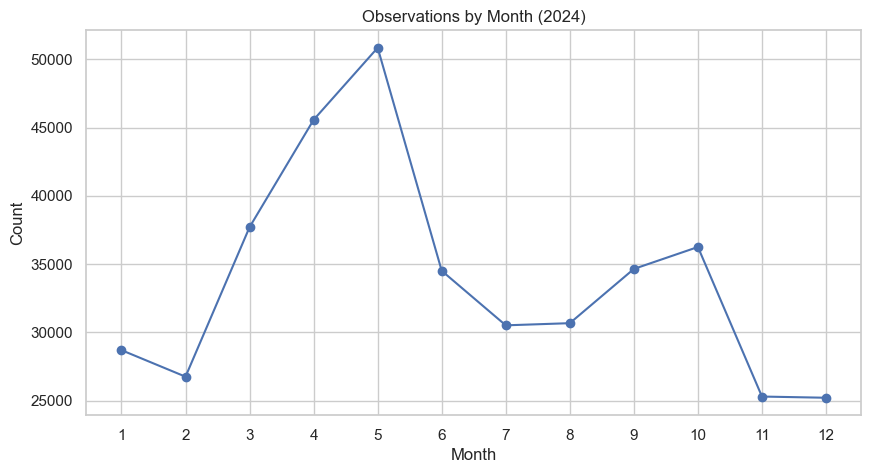

In [4]:
df_obs['month'] = df_obs['observation_date'].dt.month
plt.figure(figsize=(10, 5))
df_obs['month'].value_counts().sort_index().plot(kind='line', marker='o')
plt.title('Observations by Month (2024)')
plt.xlabel('Month')
plt.ylabel('Count')
plt.xticks(range(1, 13))
plt.show()

## 4. Integrate Weather Data

We'll pick a popular species (e.g., 'Red Kite') and fetch weather data for a sample of its observations.

In [5]:
# Filter for Red Kite
species = 'Red Kite'
df_species = df_obs[df_obs['common_name'] == species].copy()

# Sample 50 observations to demonstrate the join
df_sample = df_species.sample(50, random_state=42)

def fetch_weather_for_row(row):
    date_str = row['observation_date'].strftime('%Y-%m-%d')
    try:
        w_df = get_weather_data(row['latitude'], row['longitude'], date_str, date_str)
        # Find the hour that matches time_observations_started
        if row['time_observations_started']:
            try:
                obs_hour = int(row['time_observations_started'].split(':')[0])
                # Weather data is hourly starting at 00:00
                match = w_df.iloc[obs_hour]
                return pd.Series({
                    'temp': match['temperature_2m'],
                    'precip': match['precipitation'],
                    'wind': match['wind_speed_10m'],
                    'weather_desc': match['weather_description']
                })
            except (ValueError, IndexError):
                pass
    except Exception as e:
        pass
    return pd.Series({'temp': None, 'precip': None, 'wind': None, 'weather_desc': None})

print(f"Fetching weather for 50 samples of {species}...")
weather_stats = df_sample.apply(fetch_weather_for_row, axis=1)
df_merged = pd.concat([df_sample, weather_stats], axis=1)
df_merged = df_merged.dropna(subset=['temp'])
df_merged.head()

Fetching weather for 50 samples of Red Kite...


,common_name,latitude,longitude,observation_date,time_observations_started,month,temp,precip,wind,weather_desc
354116,Red Kite,47.381626,8.546751,2024-10-25,15:55:00,10,14.400000,0.0,3.847960,Clear sky
95474,Red Kite,47.328119,8.368524,2024-04-07,08:51:00,4,10.335999,0.0,6.638072,Partly cloudy
284059,Red Kite,47.230509,8.421252,2024-08-15,19:19:00,8,26.873001,0.0,1.527351,Mainly clear
75687,Red Kite,47.198685,7.662782,2024-03-16,08:30:00,3,7.454000,0.0,14.618837,Partly cloudy
187780,Red Kite,47.488344,8.593348,2024-05-19,10:19:00,5,14.750000,0.0,9.290511,Clear sky


## 5. Visualizing Correlations

Exploring weather conditions during sightings.

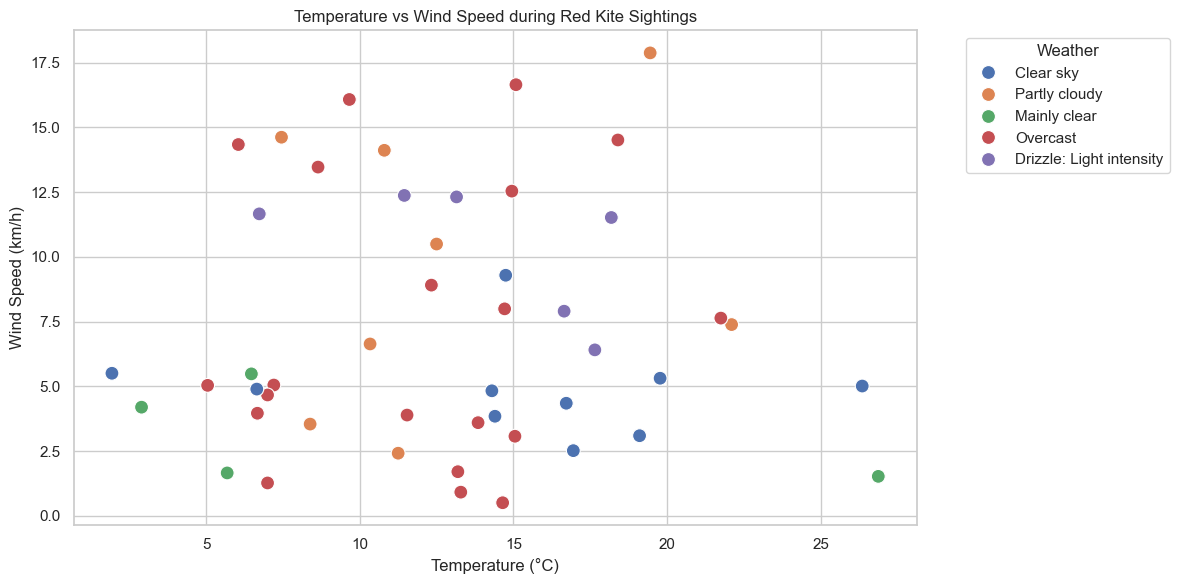

In [6]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_merged, x='temp', y='wind', hue='weather_desc', s=100)
plt.title(f'Temperature vs Wind Speed during {species} Sightings')
plt.xlabel('Temperature (°C)')
plt.ylabel('Wind Speed (km/h)')
plt.legend(title='Weather', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 6. Statistical Analysis

### 6.1 Summary Metrics

In [7]:
# Descriptive statistics for weather variables
stats_summary = df_merged[['temp', 'precip', 'wind']].describe()
print(f"Statistical summary for {species} sightings:")
stats_summary

Statistical summary for Red Kite sightings:


,temp,precip,wind
count,49.000000,49.000000,49.000000
mean,12.694674,0.022449,7.169318
std,5.758957,0.071488,4.749988
min,1.937000,0.000000,0.509117
25%,7.204000,0.000000,3.847960
50%,13.150000,0.000000,5.315336
75%,16.650000,0.000000,11.520000
max,26.873001,0.400000,17.873554


### 6.2 Weather Type Frequency

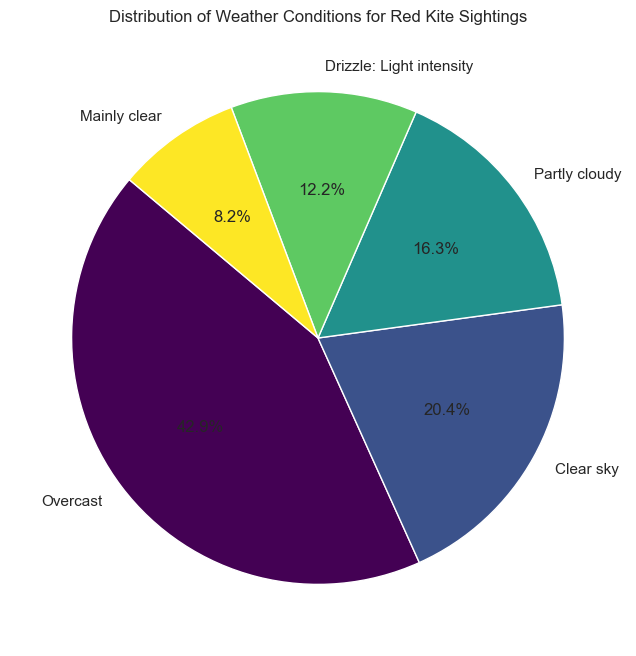

In [8]:
plt.figure(figsize=(8, 8))
df_merged['weather_desc'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=140, cmap='viridis')
plt.title(f'Distribution of Weather Conditions for {species} Sightings')
plt.ylabel('')
plt.show()

### 6.3 Correlation Matrix

Understanding the relationship between different weather variables during sightings.

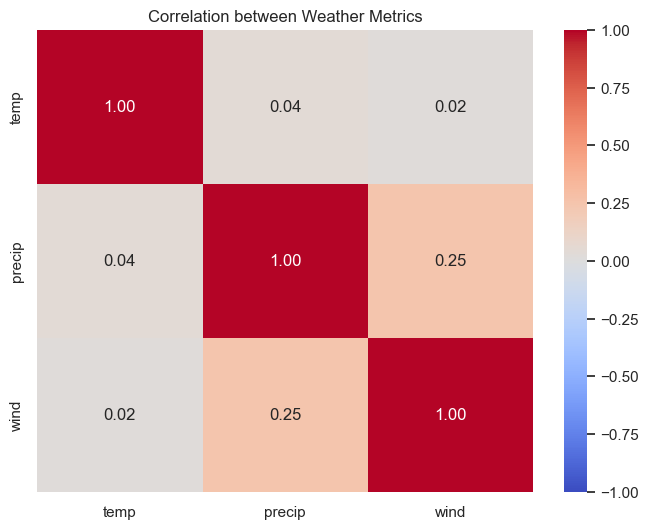

In [9]:
plt.figure(figsize=(8, 6))
corr = df_merged[['temp', 'precip', 'wind']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation between Weather Metrics')
plt.show()

### 6.4 Metric Distributions

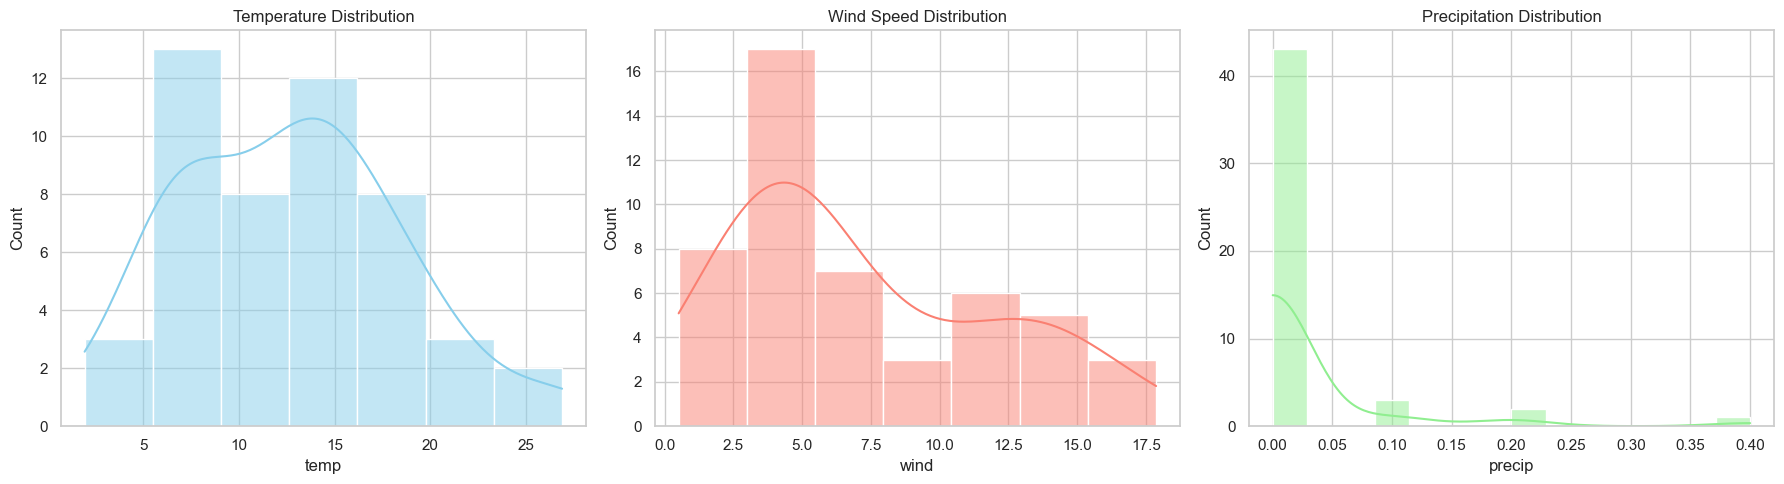

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df_merged['temp'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Temperature Distribution')

sns.histplot(df_merged['wind'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Wind Speed Distribution')

sns.histplot(df_merged['precip'], kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Precipitation Distribution')

plt.tight_layout()
plt.show()